In [1]:
# Decision Tree model notebook

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
# Load dataset (adjust path/filename)
data_path = "Dry_Bean_Dataset.csv"  
df = pd.read_excel("../data/Dry_Bean_Dataset.xlsx")

print("Data shape:", df.shape)
print(df.head())
print(df['Class'].value_counts())


Data shape: (13611, 17)
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     

In [3]:
# Separate features (X) and target (y)
# Assuming target column is named "Class"
X = df.drop(columns=['Class'])
y = df['Class']

# Encode target labels (same idea as for Logistic Regression)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded classes:", np.unique(y_encoded))


Classes: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']
Encoded classes: [0 1 2 3 4 5 6]


In [4]:
# First split: train (67%) vs temp (33%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.33,
    random_state=42,
    stratify=y_encoded
)

# Second split: temp -> val (16.5%) and test (16.5%)
# 0.5 * 0.33 ≈ 0.165
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train size:", X_train.shape[0])
print("Val size:", X_val.shape[0])
print("Test size:", X_test.shape[0])


Train size: 9119
Val size: 2246
Test size: 2246


In [5]:
# Standardize features: fit on train, transform all
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Optionally keep DataFrame versions with same column names
feature_names = X.columns
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_val_scaled_df   = pd.DataFrame(X_val_scaled, columns=feature_names)
X_test_scaled_df  = pd.DataFrame(X_test_scaled, columns=feature_names)


In [6]:
def evaluate_model(model, X, y, dataset_name="dataset"):
    """
    Print accuracy and classification report for a fitted model.
    """
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    print(f"Accuracy on {dataset_name}: {acc:.4f}")
    print(classification_report(y, y_pred, target_names=label_encoder.classes_))
    return acc


In [7]:
# Baseline Decision Tree
baseline_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

baseline_tree.fit(X_train_scaled, y_train)

print("=== Baseline Decision Tree ===")
acc_train_baseline = evaluate_model(baseline_tree, X_train_scaled, y_train, "train")
acc_val_baseline   = evaluate_model(baseline_tree, X_val_scaled,   y_val,   "validation")
acc_test_baseline  = evaluate_model(baseline_tree, X_test_scaled,  y_test,  "test")


=== Baseline Decision Tree ===
Accuracy on train: 1.0000
              precision    recall  f1-score   support

    BARBUNYA       1.00      1.00      1.00       885
      BOMBAY       1.00      1.00      1.00       350
        CALI       1.00      1.00      1.00      1092
    DERMASON       1.00      1.00      1.00      2376
       HOROZ       1.00      1.00      1.00      1292
       SEKER       1.00      1.00      1.00      1358
        SIRA       1.00      1.00      1.00      1766

    accuracy                           1.00      9119
   macro avg       1.00      1.00      1.00      9119
weighted avg       1.00      1.00      1.00      9119

Accuracy on validation: 0.8918
              precision    recall  f1-score   support

    BARBUNYA       0.87      0.89      0.88       218
      BOMBAY       0.99      1.00      0.99        86
        CALI       0.89      0.90      0.89       269
    DERMASON       0.89      0.90      0.90       585
       HOROZ       0.92      0.92      0.92 

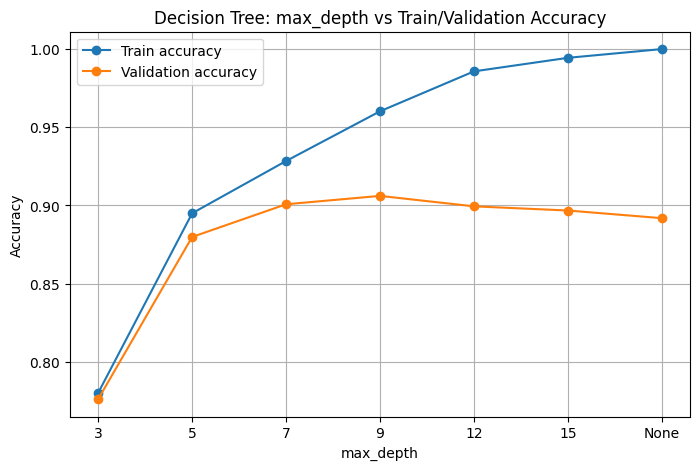

max_depth=3: train=0.7800, val=0.7760
max_depth=5: train=0.8949, val=0.8798
max_depth=7: train=0.9284, val=0.9007
max_depth=9: train=0.9602, val=0.9061
max_depth=12: train=0.9857, val=0.8994
max_depth=15: train=0.9944, val=0.8967
max_depth=None: train=1.0000, val=0.8918


In [8]:
# Hyperparameter study: max_depth
max_depth_values = [3, 5, 7, 9, 12, 15, None]

train_accuracies = []
val_accuracies   = []

for depth in max_depth_values:
    tree = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    )
    tree.fit(X_train_scaled, y_train)
    
    y_train_pred = tree.predict(X_train_scaled)
    y_val_pred   = tree.predict(X_val_scaled)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc   = accuracy_score(y_val,   y_val_pred)
    
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

# For plotting, handle None as "No limit"
x_labels = [d if d is not None else "None" for d in max_depth_values]

plt.figure(figsize=(8, 5))
plt.plot(range(len(max_depth_values)), train_accuracies, marker='o', label='Train accuracy')
plt.plot(range(len(max_depth_values)), val_accuracies,   marker='o', label='Validation accuracy')
plt.xticks(ticks=range(len(max_depth_values)), labels=x_labels)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: max_depth vs Train/Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

for depth, tr, va in zip(max_depth_values, train_accuracies, val_accuracies):
    print(f"max_depth={depth}: train={tr:.4f}, val={va:.4f}")


In [9]:
# Choose the best max_depth by validation accuracy
best_index = int(np.argmax(val_accuracies))
best_max_depth = max_depth_values[best_index]
best_val_acc = val_accuracies[best_index]

print(f"Best max_depth based on validation accuracy: {best_max_depth} "
      f"(val acc = {best_val_acc:.4f})")


Best max_depth based on validation accuracy: 9 (val acc = 0.9061)


In [10]:
# Final Decision Tree with best max_depth
final_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=best_max_depth,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

final_tree.fit(X_train_scaled, y_train)

print("=== Final Decision Tree (selected via validation) ===")
acc_train_final = evaluate_model(final_tree, X_train_scaled, y_train, "train")
acc_val_final   = evaluate_model(final_tree, X_val_scaled,   y_val,   "validation")
acc_test_final  = evaluate_model(final_tree, X_test_scaled,  y_test,  "test")


=== Final Decision Tree (selected via validation) ===
Accuracy on train: 0.9602
              precision    recall  f1-score   support

    BARBUNYA       0.96      0.94      0.95       885
      BOMBAY       1.00      1.00      1.00       350
        CALI       0.94      0.97      0.95      1092
    DERMASON       0.95      0.97      0.96      2376
       HOROZ       0.99      0.96      0.97      1292
       SEKER       0.99      0.97      0.98      1358
        SIRA       0.94      0.93      0.93      1766

    accuracy                           0.96      9119
   macro avg       0.97      0.96      0.97      9119
weighted avg       0.96      0.96      0.96      9119

Accuracy on validation: 0.9061
              precision    recall  f1-score   support

    BARBUNYA       0.88      0.89      0.89       218
      BOMBAY       0.99      1.00      0.99        86
        CALI       0.88      0.91      0.90       269
    DERMASON       0.90      0.92      0.91       585
       HOROZ       0.

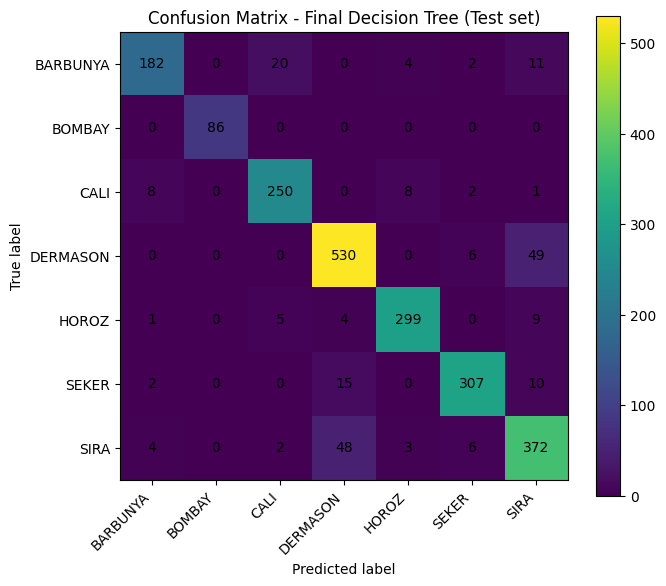

Confusion matrix (rows=true, cols=predicted):
[[182   0  20   0   4   2  11]
 [  0  86   0   0   0   0   0]
 [  8   0 250   0   8   2   1]
 [  0   0   0 530   0   6  49]
 [  1   0   5   4 299   0   9]
 [  2   0   0  15   0 307  10]
 [  4   0   2  48   3   6 372]]


In [ ]:
# Confusion matrix for final model on test set
y_test_pred = final_tree.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation='nearest')  # <-- your original style
plt.title("Confusion Matrix - Final Decision Tree (Test set)")
plt.colorbar()

tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=45, ha="right")
plt.yticks(tick_marks, label_encoder.classes_)


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center',
                 color='black')  


plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

print("Confusion matrix (rows=true, cols=predicted):")
print(cm)


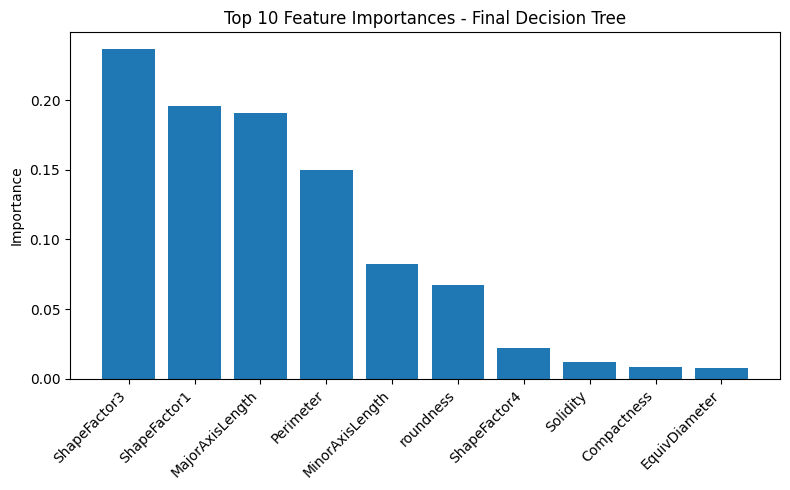

Feature importances (sorted):
ShapeFactor3: 0.2368
ShapeFactor1: 0.1954
MajorAxisLength: 0.1909
Perimeter: 0.1499
MinorAxisLength: 0.0826
roundness: 0.0676
ShapeFactor4: 0.0218
Solidity: 0.0123
Compactness: 0.0083
EquivDiameter: 0.0076


In [12]:
# Feature importances
importances = final_tree.feature_importances_
indices = np.argsort(importances)[::-1]  # sort descending

top_k = 10  # show top 10 features
top_indices = indices[:top_k]

plt.figure(figsize=(8, 5))
plt.bar(range(top_k), importances[top_indices])
plt.xticks(range(top_k), feature_names[top_indices], rotation=45, ha="right")
plt.title("Top 10 Feature Importances - Final Decision Tree")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

print("Feature importances (sorted):")
for idx in top_indices:
    print(f"{feature_names[idx]}: {importances[idx]:.4f}")
